In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [ ]:
dat = gpd.read_file('reviews_demog_2010.gpkg')

In [3]:
dat.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'gentrified', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'text',
       'date', 'geometry'],
      dtype='object')

In [4]:
# #dat = gpd.read_file('reviews_demog.gpkg')
# dat = gpd.read_file('neigh_reviews_joined.gpkg')
# reviews = pd.read_csv('philly_reviews_merged.csv')

In [5]:
# merged = pd.merge(dat, reviews, on=['business_id', 'name', 'address', 'city', 'state',
#        'latitude', 'longitude', 'review_count', 'is_open', 'attributes', 'categories', 
#        'hours'], how='left')

In [6]:
# # dat = merged
# merged.columns
# merged = merged.drop(columns = ['stars_x', 'stars_y', 'postal_code_y'])

In [7]:
# merged.columns

In [8]:
# merged = merged.dropna(subset=['categories'])
# merged = merged[merged.categories.str.contains('Restaurants')]

In [9]:
# merged.to_file("neigh_reviews_subset.gpkg")

In [10]:
# import re

# # Remove punctuation
# dat['text_processed'] = \
# dat['text'].map(lambda x: re.sub('[,\.!?]', '', x))

# # Convert the titles to lowercase
# dat['text_processed'] = \
# dat['text_processed'].map(lambda x: x.lower())

# # Print out the first rows of papers
# dat['text_processed'].head()

In [11]:

# import nltk
# from nltk.stem import PorterStemmer
# from nltk.tokenize import word_tokenize
# import string

# from nltk.corpus import stopwords

# # Download required NLTK resources
# nltk.download('punkt')
# nltk.download('stopwords')

# def clean_text(text):
#     # Initialize tools
#     stemmer = PorterStemmer()
#     stop_words = set(stopwords.words('english'))
    
#     # 1. Strip Punctuation and Lowercase
#     text = text.translate(str.maketrans('', '', string.punctuation)).lower()
    
#     # 2. Tokenize and Remove Stop Words + Stem
#     tokens = word_tokenize(text)
#     cleaned_tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    
#     return " ".join(cleaned_tokens)

# # def preprocess_text(text):
# #     # Initialize stemmer and stop words
# #     stemmer = PorterStemmer()
# #     stop_words = set(stopwords.words('english'))
    
# #     # Tokenize and convert to lowercase
# #     tokens = word_tokenize(str(text).lower())
    
# #     # Filter stopwords and apply stemming
# #     processed_tokens = [stemmer.stem(w) for w in tokens if w.isalpha() and w not in stop_words]
    
# #     return " ".join(processed_tokens)

# # Sample DataFrame
# # df = pd.DataFrame({'raw_text': [
# #     "The quick brown fox jumps over the lazy dog.",
# #     "Learning data science is incredibly exciting!"
# # ]})

# # Create the processed corpus column
# dat['corpus'] = dat['text'].apply(clean_text)

# print(dat['corpus'].head())



In [14]:
dat['text'] = dat.text.str.lower()
dat.text.head()
dat = dat.dropna(subset = ['text'])

In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

# 1. Setup (assuming 'undf' is a DataFrame)
# corpus_undf <- corpus(undf, text_field = "text")
texts = dat['text']

# 2. Preprocessing Function (tokens, remove_punct, remove_numbers, wordstem)
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # remove_punct and remove_numbers using regex
    #text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # tokens_wordstem and stopwords remove
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
processed_texts = texts.apply(preprocess)

# 3. Create DFM (Document-Feature Matrix)
# dfm <- dfm(toks)
vectorizer = CountVectorizer()
dfm = vectorizer.fit_transform(processed_texts)

# 4. Trim DFM (min_docfreq = 0.05)
# dfm_trim(dfm, min_docfreq = 0.05, docfreq_type = "prop")
trimmed_vectorizer = CountVectorizer(min_df=0.05)
dfm_trimmed = trimmed_vectorizer.fit_transform(processed_texts)

# Convert to DataFrame for viewing (optional)
dfm_trimmed_df = pd.DataFrame(
    dfm_trimmed.toarray(), 
    columns=trimmed_vectorizer.get_feature_names_out()
)

print(dfm_trimmed_df)

        actual  also  alway  amaz  anoth  appet  area  around  ask  atmospher  \
0            0     0      0     0      0      0     1       0    0          0   
1            0     0      1     0      0      0     0       0    0          0   
2            0     1      1     0      0      0     0       0    0          0   
3            0     1      0     0      0      0     0       0    0          0   
4            0     0      0     0      0      0     0       0    0          0   
...        ...   ...    ...   ...    ...    ...   ...     ...  ...        ...   
682894       0     1      0     0      0      0     0       0    0          0   
682895       0     1      0     2      0      0     0       0    0          0   
682896       0     1      0     1      0      0     0       0    0          0   
682897       0     1      0     0      0      0     0       0    0          0   
682898       0     1      0     0      2      0     0       0    0          0   

        ...  wasnt  way  we

In [16]:
# import numpy as np
# import pandas as pd
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans

# 1. Normalize the DFM (scheme="prop" in R is the L1 norm in Python)
# dfmlw <- dfm_weight(dfm, scheme="prop")
scaler = Normalizer(norm='l1')
dfmlw = scaler.fit_transform(dfm) # dfm from the previous step

# 2. Run K-Means
# K <- 25; set.seed(3456); stats::kmeans(dfmlw, centers=K)
K = 20
kmeans = KMeans(n_clusters=K, random_state=3456, n_init=10)
out1 = kmeans.fit(dfmlw)

# Get feature names (column names) from your vectorizer
feature_names = np.array(vectorizer.get_feature_names_out())
cluster_labels = out1.labels_
centers = out1.cluster_centers_

# 3. Initialize matrices for Top Words and Examples
top_words = np.empty((K, 10), dtype=object)
examples = np.empty((K, 10), dtype=object)

# 4. Extract Top Words and Document Examples
for z in range(K):
    # Calculate difference: cluster center minus mean of all other centers
    other_centers_mean = np.delete(centers, z, axis=0).mean(axis=0)
    diff = centers[z] - other_centers_mean
    
    # Get top 10 words based on the highest difference
    top_indices = np.argsort(diff)[::-1][:10]
    top_words[z, :] = feature_names[top_indices]
    
    # Get top 10 document examples (transcriptions) for this cluster
    # Assuming 'undf' is your original DataFrame with a 'Transcription' column
    cluster_docs = dat['review_id'][cluster_labels == z].values
    
    # Handle clusters with fewer than 10 documents to avoid IndexErrors
    num_examples = min(len(cluster_docs), 10)
    examples[z, :num_examples] = cluster_docs[:num_examples]

# Display top words for each cluster
top_words_df = pd.DataFrame(top_words, index=[f"Cluster {i+1}" for i in range(K)])
print(top_words_df)

                   0          1          2          3          4            5  \
Cluster 1   sandwich      chees       pork      roast      bread  cheesesteak   
Cluster 2      pizza      slice      crust      chees       sauc        order   
Cluster 3       food    restaur     chines       like    authent      qualiti   
Cluster 4       hour      happi      drink        bar    special         beer   
Cluster 5       best       ever        ive     philli        one  cheesesteak   
Cluster 6       like     flavor       dish       sauc       tast      perfect   
Cluster 7         us       tabl       wait        ask      minut         came   
Cluster 8      place  recommend       nice       amaz    favorit       philli   
Cluster 9       good       food     realli     servic      price       pretti   
Cluster 10    servic       food      excel     custom       amaz         slow   
Cluster 11     order   deliveri    chicken       call      minut        never   
Cluster 12      love      pl

In [17]:
dat[~dat["categories"].str.contains('American')].shape, dat.shape
#areas that are considered gentrified: word cloud/frequencies iin this area vs. other areas
#regress "authent", can add "price" and "service"

((449576, 25), (682899, 25))

In [18]:
dat['year'] = dat.date.str[:4].astype(int)

In [19]:
dat.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'gentrified', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'text',
       'date', 'geometry', 'year'],
      dtype='object')

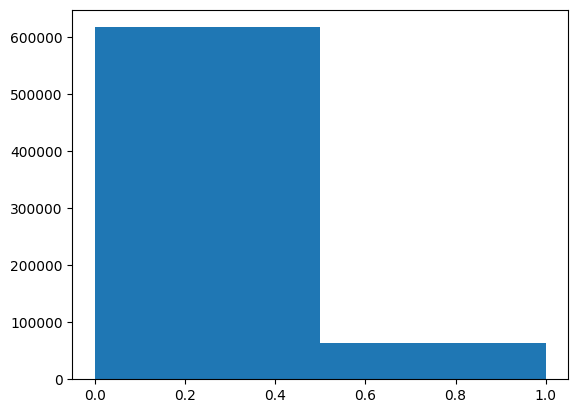

In [20]:
plt.hist(dat.gentrified, bins = 2)
plt.show()

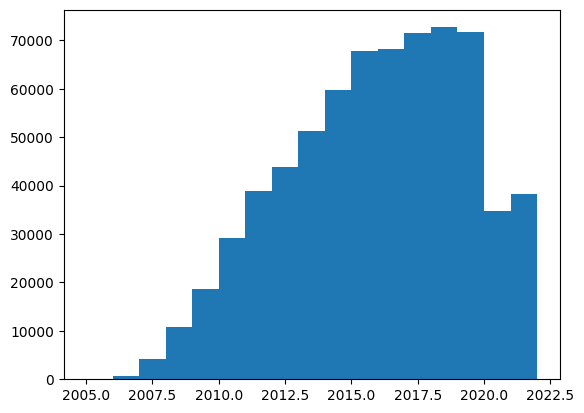

In [21]:
plt.hist(dat.year, bins = 17)
plt.show()

In [ ]:
til2015 = dat[dat.year <= 2015]

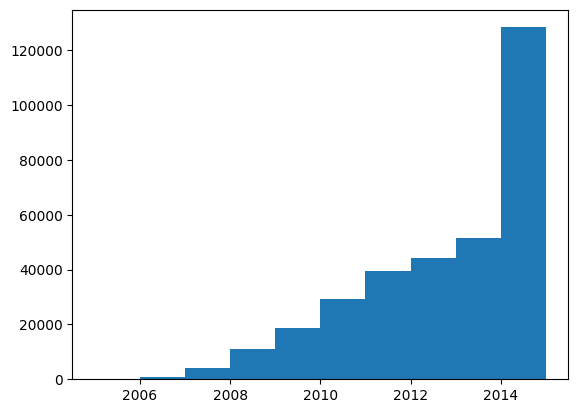

In [ ]:
plt.hist(til2015.year)
plt.show()